# 06 — From Forecast to Order: Decisions & Results

A forecast score is not the deliverable; an order is. This notebook closes the loop
by turning the probabilistic forecast and the learned policy into the artefacts a
planner actually uses — a **reorder point**, an **order-up-to level**, and a
concrete **"order N units today"** recommendation per SKU — and then reports the
end-to-end results as a **cost / fill-rate frontier** with reproducible metrics
only (no invented dollar figures).

It demonstrates three things:
1. How a quantile forecast becomes **safety stock** sized to each SKU's uncertainty.
2. A worked **daily order scenario** for SKUs from different segments.
3. The **frontier**: where the RL agent sits versus classical policies.

**Inputs:** `data/panel.parquet`, `data/segments.parquet`,
`data/neural_forecast.parquet` (if notebook 02 has run; otherwise a seasonal-quantile
fallback is built so this notebook is self-contained), and `data/rl_results.parquet`
or `data/baseline_policy_results.parquet`.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.policies import _norm_ppf
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi":110})
panel = pd.read_parquet(ROOT/"data"/"panel.parquet"); panel["date"]=pd.to_datetime(panel["date"])
segments = pd.read_parquet(ROOT/"data"/"segments.parquet")
LEAD=4; REVIEW=1; PROTECT=LEAD+REVIEW   # protection window in days (matches the twin lead time)
print("protection window:", PROTECT, "days")

protection window: 5 days


Load the neural quantile forecast if available; otherwise build an equivalent per-SKU seasonal-quantile forecast for the holdout so the order logic is identical either way.

In [2]:
QLEVELS=[0.1,0.25,0.5,0.75,0.9]
# Production forecaster = LightGBM-quantile (notebook 02b); neural is the showcase fallback.
lg_path = ROOT/"data"/"lgbm_forecast.parquet"; nf_path = ROOT/"data"/"neural_forecast.parquet"
if lg_path.exists():
    fc = pd.read_parquet(lg_path); SRC="LightGBM-quantile (notebook 02b, production)"
elif nf_path.exists():
    fc = pd.read_parquet(nf_path); SRC="neural (notebook 02)"
else:
    HOLD=28; rows=[]
    for sid,g in panel.groupby("series_id"):
        g=g.sort_values("date"); dow=g["date"].dt.dayofweek.values
        tr=g["units"].values[:-HOLD]; trd=dow[:-HOLD]
        dm={d:tr[trd==d].mean() if (trd==d).any() else tr.mean() for d in range(7)}
        sd=(tr-np.array([dm[d] for d in trd])).std()
        for (_,r),d in zip(g.iloc[-HOLD:].iterrows(), dow[-HOLD:]):
            row={"series_id":sid,"date":r["date"],"units":r["units"]}
            for q in QLEVELS: row[f"q{q}"]=max(dm[d]+_norm_ppf(q)*sd,0.0)
            rows.append(row)
    fc=pd.DataFrame(rows)
    meta=panel.groupby("series_id")[["item_id","store_id","state_id","cat_id"]].first()
    fc=fc.merge(meta,on="series_id",how="left"); SRC="seasonal-quantile fallback"
print("forecast source:", SRC, "| rows:", len(fc))

forecast source: LightGBM-quantile (notebook 02b, production) | rows: 280000


Safety stock from uncertainty: for a smooth vs a volatile SKU, show how the p-quantile gap above the median sets the safety buffer.

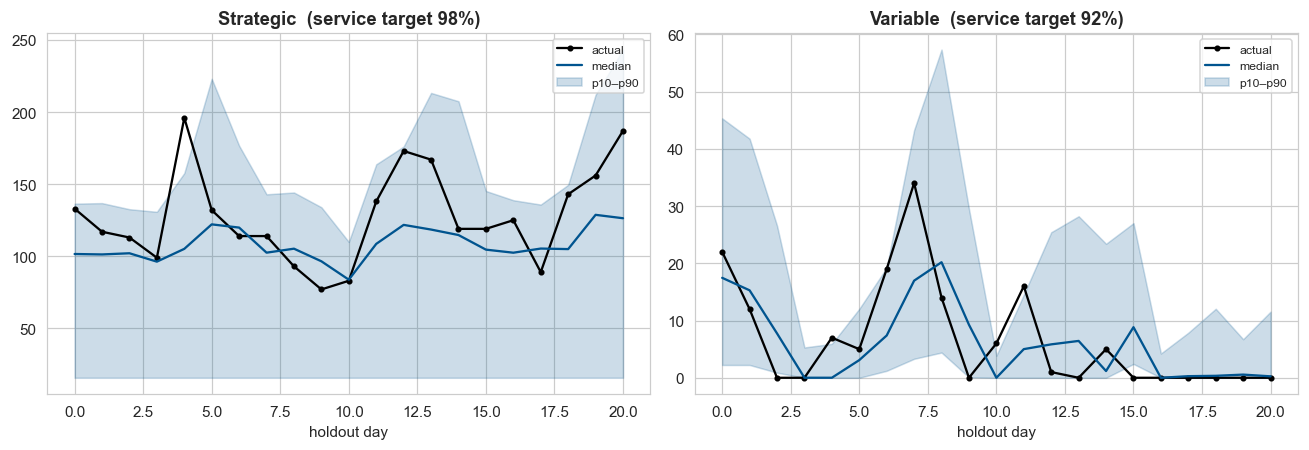

In [3]:
seg = segments.set_index("series_id")
ex = {}
for label,want in [("Strategic","Strategic (high value, predictable)"),
                   ("Variable","Variable (erratic demand)")]:
    cand = seg[seg["segment"]==want]
    if len(cand): ex[label]=cand["mean_units"].idxmax()
fig, axes = plt.subplots(1,len(ex),figsize=(6*len(ex),4.2))
if len(ex)==1: axes=[axes]
for ax,(label,sid) in zip(axes, ex.items()):
    f=fc[fc.series_id==sid].sort_values("date").head(21)
    ax.plot(range(len(f)), f["units"], "o-", color="black", ms=3, label="actual")
    ax.plot(range(len(f)), f["q0.5"], color="#00548F", label="median")
    ax.fill_between(range(len(f)), f["q0.1"], f["q0.9"], color="#00548F", alpha=.2, label="p10–p90")
    st=seg.loc[sid,"service_target"]
    ax.set_title(f"{label}  (service target {st:.0%})", fontweight="bold")
    ax.set_xlabel("holdout day"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Worked daily order scenario: for one SKU per segment, convert the forecast into an order-up-to level at its service target and a concrete order quantity given an illustrative on-hand position.

In [4]:
def lead_time_demand_quantile(fcrow_window, service):
    # approximate the protection-window demand distribution as the sum of daily
    # medians (mean) with a spread implied by the p10–p90 band, then read the
    # service quantile off a normal approximation.
    mu = fcrow_window["q0.5"].sum()
    daily_sigma = (fcrow_window["q0.9"]-fcrow_window["q0.5"]).values/_norm_ppf(0.9)
    sigma = np.sqrt(np.sum(daily_sigma**2))
    return mu, sigma, max(mu + _norm_ppf(service)*sigma, 0.0)

# protection-window median demand per SKU (used to pick a representative, non-dormant
# example per segment — max historical volume can land on a SKU that went to zero in
# the holdout, which makes a misleading 'order 0' row).
ltd = (fc.sort_values("date").groupby("series_id").head(PROTECT)
         .groupby("series_id")["q0.5"].sum())
scenarios=[]
for want in ["Strategic (high value, predictable)","Core (steady volume)",
             "Variable (erratic demand)","Long-tail (intermittent)"]:
    cand=seg[seg["segment"]==want]
    if not len(cand): continue
    # representative SKU = highest protection-window forecast demand in this segment
    sid=ltd.reindex(cand.index).fillna(0).idxmax()
    f=fc[fc.series_id==sid].sort_values("date").reset_index(drop=True)
    window=f.iloc[:PROTECT]; service=float(seg.loc[sid,"service_target"])
    mu,sigma,S=lead_time_demand_quantile(window,service)
    on_hand=round(mu*0.6); pipeline=round(mu*0.2); position=on_hand+pipeline
    order=max(round(S-position),0)
    scenarios.append({"segment":want.split(" (")[0],"sku":sid.split("--")[0][:14],
                      "service":f"{service:.0%}","exp_LTdemand":round(mu),
                      "safety_stock":round(S-mu),"order_up_to_S":round(S),
                      "on_hand":on_hand,"pipeline":pipeline,"order_today":order})
sc=pd.DataFrame(scenarios)
display(sc)
print("\nExample read: a", sc.iloc[-1]["segment"], "SKU at", sc.iloc[-1]["service"],
      "service -> order-up-to", sc.iloc[-1]["order_up_to_S"], "units; with",
      sc.iloc[-1]["on_hand"]+sc.iloc[-1]["pipeline"], "on hand+in-transit, order",
      sc.iloc[-1]["order_today"], "units today.")

,segment,sku,service,exp_LTdemand,safety_stock,order_up_to_S,on_hand,pipeline,order_today
0,Strategic,FOODS_3_090,98%,506,138,644,304,101,239
1,Core,FOODS_3_086,95%,136,46,182,81,27,74
2,Variable,FOODS_2_128,92%,78,33,111,47,16,48
3,Long-tail,FOODS_2_013,88%,162,23,185,97,32,56



Example read: a Long-tail SKU at 88% service -> order-up-to 185 units; with 129 on hand+in-transit, order 56 units today.


Headline result — the cost / fill-rate frontier across all policies (RL agent included if notebook 05 has run).

,cost,fill_rate,avg_inventory,stockout,holding
policy,,,,,
Oracle,1000367.6,1.0,12425.4,18207.7,682553.4
PPO-Residual(ours),1147974.6,1.0,15179.9,43365.7,820798.4
Newsvendor,1190384.6,1.0,15882.5,37499.1,873125.0
Base-Stock(forecast),1314021.9,1.0,18052.2,26333.5,1008530.4
Fixed-Order,2069039.6,0.9,19427.4,191969.1,1592490.8
Random,2426810.1,0.9,20806.6,272474.1,1859054.4
Min/Max,4198783.4,1.0,37783.5,14579.4,3840767.1


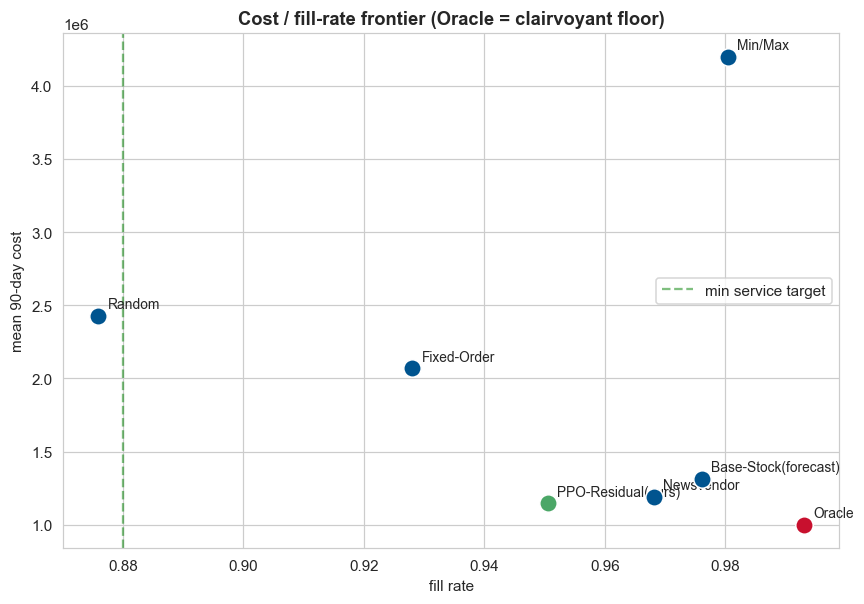

lowest-cost deployable policy: PPO-Residual(ours)


In [5]:
rl_path=ROOT/"data"/"rl_results.parquet"; bl_path=ROOT/"data"/"baseline_policy_results.parquet"
res = pd.read_parquet(rl_path) if rl_path.exists() else pd.read_parquet(bl_path)
res = res.sort_values("cost")
display(res[[c for c in ["cost","fill_rate","avg_inventory","stockout","holding"] if c in res.columns]].round(1))
deployable = res.drop(index=[i for i in ["Oracle"] if i in res.index])
best = deployable["cost"].idxmin()
fig,ax=plt.subplots(figsize=(8,5.6))
for pol,row in res.iterrows():
    c="#C8102E" if pol=="Oracle" else ("#4BA767" if "PPO" in str(pol) else "#00548F")
    ax.scatter(row["fill_rate"],row["cost"],s=130,color=c,edgecolor="white",zorder=3)
    ax.annotate(str(pol),(row["fill_rate"],row["cost"]),xytext=(6,5),textcoords="offset points",fontsize=9)
if "service_target" in segments.columns:
    ax.axvline(segments["service_target"].min(), ls="--", color="green", alpha=.5, label="min service target")
    ax.legend()
ax.set_xlabel("fill rate"); ax.set_ylabel("mean 90-day cost")
ax.set_title("Cost / fill-rate frontier (Oracle = clairvoyant floor)",fontweight="bold"); plt.tight_layout(); plt.show()
print("lowest-cost deployable policy:", best)

Reproducible metrics summary — the numbers this project actually stands behind.

In [6]:
summary = {
  "forecast_source": SRC,
  "n_series": int(panel["series_id"].nunique()),
  "holdout_days": 28,
  "best_deployable_policy": str(best),
  "best_deployable_cost_90d": round(float(deployable["cost"].min()),1),
  "best_deployable_fill_rate": round(float(deployable.loc[best,"fill_rate"]),3),
  "oracle_cost_90d": round(float(res.loc["Oracle","cost"]),1) if "Oracle" in res.index else None,
}
if "PPO-Residual(ours)" in res.index and "Newsvendor" in res.index:
    nv=res.loc["Newsvendor","cost"]; ppo=res.loc["PPO-Residual(ours)","cost"]
    summary["ppo_cost_vs_newsvendor_pct"]=round(100*(ppo-nv)/nv,1)
    summary["ppo_fill_rate"]=round(float(res.loc["PPO-Residual(ours)","fill_rate"]),3)
print("Reproducible summary:")
for k,v in summary.items(): print(f"  {k}: {v}")
pd.Series(summary).to_json(ROOT/"data"/"results_summary.json")

Reproducible summary:
  forecast_source: LightGBM-quantile (notebook 02b, production)
  n_series: 10000
  holdout_days: 28
  best_deployable_policy: PPO-Residual(ours)
  best_deployable_cost_90d: 1147974.6
  best_deployable_fill_rate: 0.95
  oracle_cost_90d: 1000367.6
  ppo_cost_vs_newsvendor_pct: -3.6
  ppo_fill_rate: 0.95
